# Introducción al Desarrollo de Modelos

## Objetivos de aprendizaje

Al finalizar esta sesión serás capaz de:
- Comprender el **flujo general de desarrollo de un modelo de machine learning**, desde la carga de datos hasta la evaluación final.  
- Utilizar **datasets reales o simulados** para plantear problemas de clasificación o regresión y dividirlos en conjuntos de entrenamiento y prueba de forma adecuada.
- Aplicar técnicas de **preprocesamiento de datos**: imputación de valores faltantes, escalado de variables numéricas y codificación de variables categóricas.  
- Combinar diferentes transformaciones mediante **`ColumnTransformer`** para crear flujos de preprocesamiento coherentes y reproducibles.  
- Integrar todo el proceso en un **`Pipeline` de scikit-learn**, unificando preprocesamiento, entrenamiento y predicción en un único objeto.  
- Entrenar modelos clásicos de machine learning (como **`LogisticRegression`**, **`DecisionTreeClassifier`** o **`RandomForestClassifier`**) y evaluar su rendimiento con métricas apropiadas.  
- Aplicar técnicas de **validación cruzada** y **optimización de hiperparámetros** con `GridSearchCV` para seleccionar el mejor modelo.  
- Interpretar y comunicar resultados mediante métricas como *accuracy*, *precision*, *recall*, *F1-score* y la *matriz de confusión*.  
- Implementar la **persistencia de modelos** con `joblib` para guardar, cargar y reutilizar pipelines entrenados en nuevos datos.  
- Comprender la **importancia de la reproducibilidad y modularidad** en los proyectos de aprendizaje automático, siguiendo buenas prácticas de experimentación.  


## 1. Preparación de entorno

> Ejecuta la siguiente celda para verificar la versión de Python y el entorno.

In [1]:
import sys, platform
print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.11.3 | packaged by Anaconda, Inc. | (main, Apr 19 2023, 23:46:34) [MSC v.1916 64 bit (AMD64)]
Executable: C:\Users\sandr\anaconda3\python.exe


> Importamos los módulos necesarios

In [2]:
import os
import numpy as np

## 2. Principios de Machine Learning y carga de datos reales

### <u>Principios de Machine Learning</u>

El **Machine Learning (ML)** es una rama de la Inteligencia Artificial cuyo objetivo es que las máquinas **aprendan patrones a partir de datos** para realizar predicciones o tomar decisiones sin ser programadas explícitamente.

En lugar de definir reglas manuales, proporcionamos **ejemplos** y el algoritmo ajusta automáticamente un modelo.

---

#### 1. Tipos de aprendizaje

1. **Aprendizaje supervisado**  
   - Entrenamos con un conjunto de datos que incluye **entradas (features, X)** y **salidas conocidas (labels, y)**.  
   - El modelo aprende a mapear entradas → salidas.  
   - Ejemplos:
     - Clasificación: predecir si un email es *spam* o *no spam*.  
     - Regresión: predecir el precio de una casa en función de sus características.  
   - Métricas típicas: Accuracy, Precision, Recall, F1, RMSE.

2. **Aprendizaje no supervisado**  
   - Solo tenemos las **entradas (X)**, no hay etiquetas.  
   - El modelo busca **estructuras ocultas** en los datos.  
   - Ejemplos:
     - Clustering: agrupar clientes por comportamiento de compra.  
     - Reducción de dimensionalidad: PCA para visualizar datos de alta dimensión.  
   - Métricas típicas: Inercia, Silhouette score, Varianza explicada.

3. **Aprendizaje por refuerzo**  
   - Un agente aprende a actuar en un entorno recibiendo **recompensas o penalizaciones**.  
   - Ejemplo: un robot que aprende a caminar, o un sistema que juega al ajedrez.  
   - (Lo mencionamos para cultura general, pero no lo trabajaremos en esta asignatura).

---

#### 2. Conjuntos de datos: Train, Validation y Test

Al entrenar un modelo, no basta con usar todos los datos:  
- **Train set** → el modelo aprende aquí los patrones.  
- **Validation set** → se usa para medir el rendimiento del modelo en cada iteración.
- **Test set** → datos *nunca vistos* que simulan el mundo real y miden el rendimiento final.  

Si entrenamos y probamos en los mismos datos → el modelo memoriza (overfitting) y falla en nuevos ejemplos.

En `scikit-learn` tenemos la función `train_test_split` para separar train/test.  
Más adelante veremos también **cross-validation**, donde se repite la validación en múltiples particiones.

Cuando dividimos un dataset en **train/validation/test**, debemos asegurarnos de que la distribución de clases (en clasificación) o de valores (en algunos casos de regresión) se mantenga representativa. Si no lo hacemos, corremos el riesgo de que:
- El conjunto de entrenamiento tenga una distribución muy distinta al test.
- Alguna clase quede **subrepresentada o incluso desaparezca** en validación/test.

**Ejemplo sin estratificación**
Si tenemos 100 muestras:
- 90 de clase A  
- 10 de clase B  

Un `train_test_split` aleatorio podría dejar todas las de clase B en train, y ninguna en test → el modelo parecería perfecto en test, pero en realidad no sabe detectar B.

Para evitarlo, `train_test_split` tiene el parámetro `stratify=y`.  
Esto asegura que **la proporción de clases se mantenga en cada conjunto**.

#### 3. Métricas comunes de evaluación

- **Clasificación**:
  - **Accuracy**: % de aciertos totales.
  - **Precision**: de los que predije como positivos, ¿cuántos lo eran de verdad?
  - **Recall (sensibilidad)**: de los positivos reales, ¿cuántos encontré?
  - **F1-score**: balance entre precision y recall.
  - (Para problemas desbalanceados, accuracy puede ser engañoso).

- **Regresión**:
  - **MSE (Mean Squared Error)**: error cuadrático medio.
  - **RMSE**: raíz cuadrada del MSE, interpretable en las mismas unidades de la variable objetivo.
  - **MAE (Mean Absolute Error)**: error absoluto medio, más robusto a outliers.

---

#### 4. Preparación de datos

Antes de entrenar, es esencial:
- Separar **features (X)** y **labels (y)**.
- Normalizar o escalar valores si es necesario.
- Manejar datos faltantes o ruidosos.
- Garantizar **reproducibilidad** con `random_state` → para que todos veamos los mismos resultados al dividir datos o inicializar modelos.

---

#### 5. Ciclo de vida típico de un proyecto de ML

1. **Recolección de datos** (datasets internos, externos, open data).  
2. **Preparación** (limpieza, transformación, división train/val/test).  
3. **Entrenamiento** del modelo en train set.  
4. **Validación** de hiperparámetros en validation set (grid search, cross-validation).  
5. **Evaluación final** en test set.  
6. **Despliegue** en producción.  
7. **Monitoreo** y mantenimiento del modelo (drift de datos).  

---


### <u>Ejemplo 1: Dataset de juguete `iris`</u>

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Cargar dataset incluido
iris = load_iris(as_frame=True)

# Features (X) y labels (y)
X = iris.data
y = iris.target
print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32


### <u>Ejemplo 2: División de datos `train`/`test`</u>

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)

Tamaño train: (120, 4)
Tamaño test: (30, 4)


### <u>Ejemplo 3: División de datos `train`/`test` con estratificación</u>

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import numpy as np

X, y = load_iris(return_X_y=True)

# División sin estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Distribución train (sin estratificación):", np.bincount(y_train))
print("Distribución test  (sin estratificación):", np.bincount(y_test))

# División con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("\nDistribución train (estratificado):", np.bincount(y_train))
print("Distribución test  (estratificado):", np.bincount(y_test))

Distribución train (sin estratificación): [31 37 37]
Distribución test  (sin estratificación): [19 13 13]

Distribución train (estratificado): [35 35 35]
Distribución test  (estratificado): [15 15 15]


In [6]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### <u>Ejemplo 4: Métricas</u>

In [7]:
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error
import numpy as np

# Clasificación (ejemplo ficticio)
y_true = [0, 1, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1-score:", f1_score(y_true, y_pred))

# Regresión (ejemplo ficticio)
y_true = [3.0, 2.5, 4.1]
y_pred = [2.8, 2.7, 4.0]
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Accuracy: 0.8
F1-score: 0.8
RMSE: 0.17320508075688779


## 3. Algoritmos Clásicos

En esta sección aprenderás a entrenar, hacer predicciones y evaluar algunos de los **modelos clásicos** más usados en Machine Learning con `scikit-learn`.

`scikit-learn` implementa una interfaz **unificada** para todos sus modelos:
- `fit(X_train, y_train)` → entrena el modelo.
- `predict(X_test)` → genera predicciones.
- `score(X_test, y_test)` → devuelve una métrica rápida (accuracy o R²).

### <u>**Regresión**</u>
#### ¿Qué es la regresión?

La **regresión** es un tipo de aprendizaje supervisado que busca **predecir valores numéricos continuos** a partir de variables de entrada.

Ejemplos:
- Predecir el precio de una vivienda según su tamaño, ubicación, y número de habitaciones.
- Estimar el consumo energético de una máquina según su carga.

En términos matemáticos, la regresión intenta encontrar una función f(X) f(X)  que se aproxime a las etiquetas reales y y .

#### <u>Modelo: `LinearRegression`</u>
El modelo de **Regresión Lineal** busca ajustar una **recta (o hiperplano)** que mejor explique la relación entre las variables de entrada (**features**) y la salida (**target**).

Ecuación general:
$$
\hat{y} = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n
$$

In [8]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import plotly.io as pio
pio.renderers.default = "notebook_connected"  # establece renderer

# Datos sintéticos
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluación
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Visualización interactiva
df_plot = pd.DataFrame({
    "X_test": X_test.flatten(),
    "y_test": y_test.flatten(),
    "y_pred": y_pred.flatten()
}).sort_values("X_test")

fig = px.scatter(df_plot, x="X_test", y="y_test", color_discrete_sequence=["blue"], opacity=0.7,
                 title="Regresión Lineal — Relación entre X e y")
fig.add_scatter(x=df_plot["X_test"], y=df_plot["y_pred"], mode="lines", name="Recta ajustada", line=dict(color="red"))
fig.update_layout(xaxis_title="X (Conjunto de características de test)", yaxis_title="y (ground truth)")
fig.show()

R²: 0.8072059636181392
RMSE: 0.8085168605026132


#### Métricas de regresión

- **R² (Coeficiente de determinación)**: mide qué proporción de la variabilidad de `y` es explicada por el modelo.  
  - Valores cercanos a **1** indican un buen ajuste.  
  - Valores negativos implican que el modelo es peor que una media constante.

- **RMSE (Root Mean Squared Error)**: mide el error promedio entre las predicciones y los valores reales, en las **mismas unidades que la variable objetivo**.  
  - Cuanto más bajo, mejor.  
  - Penaliza más los errores grandes que los pequeños.

### <u>**Clasificación**</u>
#### ¿Qué es la clasificación?

La **clasificación** es otro tipo de aprendizaje supervisado que busca **predecir etiquetas categóricas o discretas**.  
En otras palabras, la clasificación busca **asignar una etiqueta** a cada muestra de entrada.

Ejemplos:
- Predecir si un email es *spam* o *no spam*.
- Determinar el tipo de flor (setosa, versicolor o virginica) según sus medidas.
- Detectar si una imagen contiene un gato o un perro.

A diferencia de la regresión, aquí las salidas son **clases** y no números continuos.  
El modelo aprende **fronteras de decisión** que separan las clases.

#### <u>Modelo: `LogisticRegression`</u>
Aunque su nombre diga “Regression”, **LogisticRegression** se usa para **clasificación binaria o multiclase**.

Aprende una frontera lineal que separa las clases mediante una función sigmoide, es decir, usa dicha función para estimar probabilidades.

Ecuación general:
$$
P(y=1|x) = \frac{1}{1 + e^{-(w·x + b)}}
$$

In [9]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Dataset bidimensional para visualizar
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                           random_state=42, n_clusters_per_class=1)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Entrenamiento
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

# --- Visualización coherente ---
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

df_test = pd.DataFrame({
    "x1": X_test[:, 0],
    "x2": X_test[:, 1],
    "true_label": y_test,
    "pred_label": y_pred
})

df_test["correcto"] = np.where(df_test["true_label"] == df_test["pred_label"], "✔️ Correcto", "❌ Error")

# Plotly
fig = px.scatter(df_test, x="x1", y="x2", color="correcto",
                 symbol="true_label",
                 title="Clasificación con Logistic Regression — Frontera + Aciertos/Errores",
                 color_discrete_map={"✔️ Correcto": "#00CC96", "❌ Error": "#EF553B"},
                 symbol_map={0: "circle", 1: "x"})

# Añadir frontera de decisión
fig.add_contour(x=np.linspace(x_min, x_max, 200),
                y=np.linspace(y_min, y_max, 200),
                z=Z, showscale=False, opacity=0.25,
                colorscale=[[0, "#00CC96"], [1, "#EF553B"]],
                name="Frontera")

fig.update_layout(xaxis_title="Feature 1", yaxis_title="Feature 2")
fig.show()

Accuracy: 0.9444444444444444


              precision    recall  f1-score   support

           0       0.98      0.91      0.94        45
           1       0.92      0.98      0.95        45

    accuracy                           0.94        90
   macro avg       0.95      0.94      0.94        90
weighted avg       0.95      0.94      0.94        90



#### Métricas de clasificación

- **Accuracy (Exactitud)**: proporción de aciertos sobre el total de muestras.  
  - Adecuada cuando las clases están balanceadas.

- **Precision (Precisión)**: de los elementos que el modelo predijo como positivos, ¿cuántos lo eran realmente?  
  - Penaliza falsos positivos.

- **Recall (Sensibilidad o Exhaustividad)**: de los positivos reales, ¿cuántos encontró el modelo?  
  - Penaliza falsos negativos.

- **F1-score**: media armónica entre precisión y recall.  
  - Útil cuando hay **clases desbalanceadas**, pues combina ambas medidas.

#### <u>Modelo: `K-Nearest Neighbors`</u>

El algoritmo **K-Nearest Neighbors** (KNN) es uno de los modelos más simples y a la vez más intuitivos del Machine Learning.  
No “aprende” una función matemática como otros modelos (no tiene entrenamiento propiamente dicho), sino que **memoriza** los datos de entrenamiento.

Cuando llega un nuevo punto que queremos clasificar, el algoritmo:

1. Calcula la **distancia** desde ese punto a todos los ejemplos del conjunto de entrenamiento.  
2. Selecciona los **K vecinos más cercanos** (de ahí su nombre).  
3. Asigna la **clase más frecuente** entre esos vecinos como predicción.

**Parámetros principales**:

- `n_neighbors`: número de vecinos a considerar (K).  
  - Si `K` es muy pequeño → el modelo será sensible al ruido (*sobreajuste*).  
  - Si `K` es muy grande → las predicciones serán muy suaves (*subajuste*).  

- `metric`: define la distancia usada (por defecto, **euclídea**).  
  También pueden usarse Manhattan (`p=1`) o Minkowski (`p` general).

- `weights`: si se pone `"distance"`, los vecinos más cercanos tienen más peso en la decisión.

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Dataset no lineal (ideal para KNN)
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Entrenamiento del modelo
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predicciones
y_pred = knn.predict(X_test)

# Métricas
print(classification_report(y_test, y_pred))

# --- Visualización ---

# Malla de decisión
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# DataFrame para los puntos de test
df_test = pd.DataFrame({
    "x1": X_test[:, 0],
    "x2": X_test[:, 1],
    "true_label": y_test,
    "pred_label": y_pred
})

# Colores por clase predicha
color_map = {0: "#00CC96", 1: "#EF553B"}

# Gráfico Plotly
fig = go.Figure()

# Fondo: frontera de decisión
fig.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, 200),
    y=np.linspace(y_min, y_max, 200),
    z=Z,
    showscale=False,
    opacity=0.25,
    colorscale=["#00CC96", "#EF553B"]
))

# Puntos de test
fig.add_trace(go.Scatter(
    x=df_test["x1"],
    y=df_test["x2"],
    mode="markers",
    marker=dict(
        size=9,
        color=[color_map[p] for p in df_test["pred_label"]],
        line=dict(width=1, color="black")
    ),
    name="Test set"
))

fig.update_layout(
    title=f"Frontera de decisión — KNN (K=5)",
    xaxis_title="Feature 1",
    yaxis_title="Feature 2"
)

fig.show()

              precision    recall  f1-score   support

           0       0.97      0.82      0.89        45
           1       0.85      0.98      0.91        45

    accuracy                           0.90        90
   macro avg       0.91      0.90      0.90        90
weighted avg       0.91      0.90      0.90        90



#### <u>Modelo: `Random Forest`</u>

Un **Random Forest** (Bosque Aleatorio) es un modelo de **aprendizaje en conjunto (ensemble)** basado en árboles de decisión.

La idea principal es:
- Entrenar **muchos árboles de decisión independientes** sobre **subconjuntos aleatorios** del dataset.
- Cada árbol da su **predicción individual**.
- El modelo final decide **por votación mayoritaria** (en clasificación) o **promedio** (en regresión).

De esta forma se reducen los principales problemas del árbol de decisión individual:
- Menor **sobreajuste** (overfitting).
- Mayor **robustez** frente al ruido.
- Mejor **precisión promedio**.

**Parámetros principales**:

- `n_estimators`: número de árboles del bosque.  
  Más árboles → más estabilidad, pero mayor coste computacional.

- `max_depth`: profundidad máxima de cada árbol (controla el sobreajuste).

- `max_features`: número de variables consideradas al dividir cada nodo (introduce aleatoriedad).

- `random_state`: asegura reproducibilidad del resultado.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Dataset no lineal
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Entrenamiento del modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred = rf.predict(X_test)

# Métricas
print(classification_report(y_test, y_pred))

# --- Visualización coherente ---
# Malla para frontera
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = rf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# DataFrame con datos de test
df_test = pd.DataFrame({
    "x1": X_test[:, 0],
    "x2": X_test[:, 1],
    "true_label": y_test,
    "pred_label": y_pred
})

# Identificar errores
df_test["es_error"] = df_test["true_label"] != df_test["pred_label"]

# Paleta de colores por clase real
color_map = {0: "#00CC96", 1: "#EF553B"}  # verde / rojo

fig = go.Figure()

# Fondo: frontera de decisión (predicción del modelo)
fig.add_trace(go.Contour(
    x=np.linspace(x_min, x_max, 200),
    y=np.linspace(y_min, y_max, 200),
    z=Z,
    showscale=False,
    opacity=0.25,
    colorscale=["#00CC96", "#EF553B"],
    name="Frontera de decisión"
))

# Puntos de test (coloreados según clase real)
fig.add_trace(go.Scatter(
    x=df_test["x1"],
    y=df_test["x2"],
    mode="markers",
    marker=dict(
        size=9,
        color=[color_map[t] for t in df_test["true_label"]],
        line=dict(width=1, color="black")
    ),
    name="Datos de test"
))

# Círculo grueso en los errores
errores = df_test[df_test["es_error"]]
fig.add_trace(go.Scatter(
    x=errores["x1"],
    y=errores["x2"],
    mode="markers",
    marker=dict(
        size=13,
        color="rgba(0,0,0,0)",
        line=dict(width=3, color="black")
    ),
    name="Errores"
))

fig.update_layout(
    title=f"Random Forest — Frontera de decisión y errores",
    xaxis_title="Feature 1",
    yaxis_title="Feature 2",
    legend_title="Leyenda",
    width=700,
    height=500
)

fig.show()

              precision    recall  f1-score   support

           0       0.97      0.84      0.90        45
           1       0.86      0.98      0.92        45

    accuracy                           0.91        90
   macro avg       0.92      0.91      0.91        90
weighted avg       0.92      0.91      0.91        90



### <u>**Clustering**</u>
#### ¿Qué es el clustering?

El **clustering** es una técnica de aprendizaje **no supervisado**: el algoritmo agrupa las muestras según su **similitud**, sin conocer etiquetas previas.

Objetivo:
- Descubrir **patrones o grupos naturales** en los datos.
- Útil para exploración, segmentación de clientes, detección de anomalías, etc.

Ejemplos:
- Agrupar documentos por temática.
- Segmentar clientes según hábitos de compra.
- Detectar grupos en datos biológicos o de sensores.

#### <u>Modelo: `K-Means`</u>

El algoritmo **K-Means** agrupa los datos en `k` clústeres, asignando cada punto al centro más cercano.

Pasos:
1. Inicializar aleatoriamente `k` centroides.
2. Asignar cada muestra al centro más cercano.
3. Recalcular los centroides como la media de cada grupo.
4. Repetir hasta converger (los centroides no cambian significativamente).

El número de clústeres `k` se define **a priori**.

In [12]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import plotly.express as px
from sklearn.metrics import silhouette_score

# Dataset con 3 clústeres
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.7, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Evaluación
score = silhouette_score(X, kmeans.labels_)
print(f"Silhouette Score: {score:.3f}")

df_clusters = pd.DataFrame(X, columns=["x", "y"])
df_clusters["cluster"] = kmeans.labels_

fig = px.scatter(df_clusters, x="x", y="y", color=df_clusters["cluster"].astype(str),
                 title="Clustering con K-Means", color_discrete_sequence=px.colors.qualitative.Bold)
fig.add_scatter(x=kmeans.cluster_centers_[:, 0],
                y=kmeans.cluster_centers_[:, 1],
                mode="markers", marker_symbol="x", marker_color="black", marker_size=14,
                name="Centroides")
fig.show()

C:\Users\sandr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

C:\Users\sandr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.



Silhouette Score: 0.893


#### Métricas de clustering

- **Silhouette Score**: compara la distancia promedio entre un punto y los de su propio clúster frente a los de otros clústeres.  
  - Varía entre **-1** (malo) y **1** (bueno).  
  - Valores altos indican clústeres bien separados y compactos.

### <u>**Resumen de pasos comunes**</u>

1. Cargar los datos.
2. Separar features (X) y etiquetas (y) si aplica.
3. Dividir en conjuntos train/test.
4. Crear modelo → `model = ClaseModelo(...)`.
5. Entrenar → `model.fit(X_train, y_train)`.
6. Predecir → `y_pred = model.predict(X_test)`.
7. Evaluar → métricas (`accuracy_score`, `r2_score`, etc.).
8. Visualizar → frontera de decisión o resultados.

### 📝 **Ejercicios**

1. Carga el dataset `load_wine` de scikit-learn.  
2. Entrena los siguientes modelos:  
   - `LogisticRegression`  
   - `KNeighborsClassifier`  
   - `RandomForestClassifier`  
3. Evalúa los tres modelos sobre el mismo conjunto de test.  
4. Compara sus resultados usando `accuracy` y `f1-score`.  
5. Ajusta el parámetro `max_depth` del árbol y observa si aparece sobreajuste.

## 4. Evaluación de modelos y Métricas

Hasta ahora hemos aprendido a **entrenar modelos** de Machine Learning y a generar predicciones.  
Pero… ¿cómo sabemos si un modelo es realmente **bueno** o simplemente está memorizando los datos?

La **evaluación de modelos** es la parte que nos permite medir su rendimiento de forma objetiva, comparar algoritmos y detectar problemas como el **sobreajuste** (*overfitting*) o el **subajuste** (*underfitting*).

En esta sección aprenderás:
- Cómo dividir correctamente los datos.
- Qué es y cómo aplicar la **validación cruzada**.
- Cómo elegir la **métrica adecuada** según el tipo de problema.
- Cómo interpretar **reportes de clasificación** y **matrices de confusión**.
- Cómo evaluar también los modelos de **regresión**.

### <u>División `train`/`test` con `train_test_split`</u>

El primer paso de una buena evaluación es **reservar parte de los datos para probar el modelo**.  
Esto se hace con la función `train_test_split`.

- **Train set** → se usa para **entrenar** el modelo (ajustar los parámetros).
- **Test set** → se usa para **evaluar** el modelo con datos *no vistos*.

Esto es esencial para medir **la capacidad de generalización** del modelo, es decir, cómo se comporta con datos nuevos.

**Documentacion oficial: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html**

In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} muestras")
print(f"Tamaño del conjunto de test         : {len(X_test)}  muestras")

Tamaño del conjunto de entrenamiento: 105 muestras
Tamaño del conjunto de test         : 45  muestras


**Importante:**  
La opción `stratify=y` garantiza que las proporciones de las clases (por ejemplo, tipo de flor) se mantengan iguales en train y test.  
Esto es fundamental en clasificación, sobre todo cuando hay clases minoritarias.

### <u>Validación cruzada con `cross_val_score`</u>

Una sola división train/test puede ser **poco representativa**, ya que depende del azar.  
Por ejemplo, podríamos tener una muestra más difícil en el test o una distribución distinta de clases.

Para obtener una evaluación más robusta usamos la **validación cruzada** (*Cross-Validation*).

**¿Cómo funciona?**:
1. Se divide el dataset en `k` partes (o *folds*).
2. Se entrena el modelo `k` veces:
   - En cada iteración, se usan `k-1` folds para entrenar y el fold restante para evaluar.
3. Se promedian las métricas obtenidas en cada iteración.

Este proceso reduce la varianza y ofrece una medida más estable del rendimiento del modelo.

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

X, y = load_iris(return_X_y=True)
model = LogisticRegression(max_iter=200)

scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print("Accuracy en cada fold:", scores)
print("Media de accuracy    :", np.mean(scores).round(3))
print("Desviación estándar  :", np.std(scores).round(3))

Accuracy en cada fold: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Media de accuracy    : 0.973
Desviación estándar  : 0.025


Cuanto **menor sea la desviación estándar**, más estable y consistente es el modelo. Esto nos da confianza en su capacidad de generalización.

### <u>Validación estratificada con `StratifiedKFold`</u>

En clasificación, no todas las clases aparecen con la misma frecuencia.  
Por ejemplo, podríamos tener 90% de clase A y solo 10% de clase B.

La validación cruzada normal podría generar folds donde una clase casi no aparece, lo cual distorsiona la evaluación.  
Para evitarlo, usamos `StratifiedKFold`, que **mantiene la proporción de clases en cada partición**.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

print("Scores estratificados:", scores)
print("Accuracy medio:", np.mean(scores).round(3))

Scores estratificados: [1.         0.96666667 0.93333333 1.         0.93333333]
Accuracy medio: 0.967


### <u>Métricas de clasificación</u>

Una métrica es una **forma cuantitativa de medir el rendimiento** de un modelo.

No existe una métrica universal; la elección depende del contexto del problema.

Por ejemplo:
- En detección de fraude, es más importante detectar todos los casos sospechosos (alto **recall**).
- En detección de SPAM, no queremos que correos que no lo son nos los redirija (alta **precision**).

#### **Métricas principales:**

| Métrica | Qué mide | Fórmula conceptual |
|----------|-----------|-------------------|
| **Accuracy** | Proporción total de aciertos. | (TP + TN) / (Total) |
| **Precision** | Fiabilidad de los positivos predichos. | TP / (TP + FP) |
| **Recall (Sensibilidad)** | Capacidad de detectar positivos reales. | TP / (TP + FN) |
| **F1-score** | Equilibrio entre precision y recall. | 2 × (P × R) / (P + R) |

In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=44, stratify=y
)

clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 6))
print("Precision:", round(precision_score(y_test, y_pred, average='macro'), 6))
print("Recall   :", round(recall_score(y_test, y_pred, average='macro'), 6))
print("F1-score :", round(f1_score(y_test, y_pred, average='macro'), 6))

Accuracy : 0.933333
Precision: 0.944444
Recall   : 0.933333
F1-score : 0.93266


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "LogisticRegression": LogisticRegression(max_iter=500)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred, average="macro"),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro")
    })

df_results = pd.DataFrame(results).melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

fig = px.bar(
    df_results, x="Métrica", y="Valor", color="Modelo",
    barmode="group", text="Valor",
    title="Comparación de Métricas entre Modelos",
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_traces(texttemplate='%{text:.3f}', textposition="outside")
fig.update_layout(yaxis_range=[0, 1])
fig.show()

In [18]:
from sklearn.model_selection import validation_curve
import numpy as np

# Analizamos el efecto de max_depth en un Random Forest
param_range = np.arange(1, 20)
train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X, y,
    param_name="max_depth",
    param_range=param_range,
    scoring="accuracy",
    cv=5
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

df_curve = pd.DataFrame({
    "max_depth": param_range,
    "Train Accuracy": train_mean,
    "Test Accuracy": test_mean
})
df_curve = df_curve.melt(id_vars="max_depth", var_name="Dataset", value_name="Accuracy")

fig = px.line(
    df_curve, x="max_depth", y="Accuracy", color="Dataset",
    title="Curva de Validación — Profundidad del Árbol (Random Forest)",
    markers=True
)
fig.update_layout(xaxis_title="max_depth", yaxis_range=[0, 1])
fig.show()

**Interpretación:**
- Si `train_accuracy` es mucho mayor que `test_accuracy`, el modelo está **sobreajustando**.  
- Si ambos valores son bajos, el modelo está **subajustando**.  
- El punto donde ambas curvas se estabilizan suele indicar una **buena complejidad** del modelo.

#### **Reporte detallado por clase:**

In [19]:
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=load_iris().target_names))


Classification report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.83      1.00      0.91        15
   virginica       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



Cada fila corresponde a una clase, mostrando sus métricas individuales. También se incluyen tres promedios:
- **macro avg** → media simple de las métricas de cada clase (todas las clases pesan igual).  
- **weighted avg** → media ponderada por la cantidad de ejemplos por clase.  
- **accuracy** → global (micro promedio).

#### **Matriz de confusión:**

La **matriz de confusión** permite ver en detalle cómo el modelo confunde las clases.

- Cada fila → clase real.  
- Cada columna → clase predicha.

Un modelo perfecto tendría todos los valores en la diagonal principal.

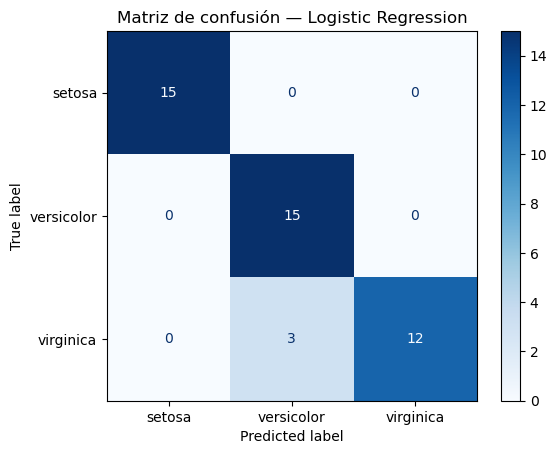

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=load_iris().target_names)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión — Logistic Regression")
plt.show()

### <u>Métricas de regresión</u>

En regresión el objetivo es predecir valores **numéricos continuos**, por ejemplo, el precio de una casa o la temperatura de mañana.

Las métricas más comunes son:

| Métrica                               | Qué mide                                                                 |
| ------------------------------------- | ------------------------------------------------------------------------ |
| **MSE (Mean Squared Error)**          | Error cuadrático medio. Penaliza fuertemente los errores grandes.        |
| **RMSE (Root MSE)**                   | Raíz del MSE, expresada en las mismas unidades que la variable objetivo. |
| **MAE (Mean Absolute Error)**         | Error medio absoluto, más robusto a valores extremos.                    |
| **R² (Coeficiente de determinación)** | Cuánta varianza del target explica el modelo.                            |

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

MSE : 0.556
RMSE: 0.746
MAE : 0.533
R²  : 0.576


### <u>¿Cuándo usar cada métrica?</u>

| Tipo de problema | Métricas recomendadas | Cuándo usar |
|------------------|------------------------|--------------|
| **Clasificación balanceada** | `accuracy`, `f1_score`, `confusion_matrix` | Cuando todas las clases son igual de importantes. |
| **Clasificación desbalanceada** | `precision`, `recall`, `f1`, `confusion_matrix` | Cuando hay clases raras (fraude, enfermedad…). |
| **Regresión** | `RMSE`, `MAE`, `R²` | Para cuantificar cuánto se desvía la predicción. |

### 📝 **Ejercicios**

1. Carga el dataset `load_wine` de scikit-learn.  
2. Aplica un `RandomForestClassifier`.  
3. Evalúalo con:
    - `cross_val_score` (5 folds, `accuracy`).
    - `classification_report`.
    - `confusion_matrix`.
4. Interpreta los resultados:
    - ¿Qué clase se confunde más?
    - ¿Cuál tiene mejor recall?
    - Si quisieras **minimizar falsos negativos**, ¿qué métrica priorizarías?
5. Repite con `LogisticRegression` y compara los resultados.
6. Finalmente, visualiza ambas matrices de confusión y comenta las diferencias.

## 5. Preprocesamiento y pipelines

Los modelos de Machine Learning **no trabajan directamente con datos crudos**, necesitan que las variables estén **limpias, codificadas y escaladas**.

Por ello, antes de entrenar un modelo, debemos asegurarnos de que los datos estén:
- En el formato correcto (numéricos, sin valores nulos ni inconsistencias).
- En escalas comparables.
- Representados de forma adecuada si contienen texto o categorías.

El **preprocesamiento** es el conjunto de pasos que transforman los datos *crudos* en un formato que los modelos pueden entender.

En esta sección aprenderás:
- Cómo escalar variables numéricas.
- Cómo codificar variables categóricas.
- Cómo imputar valores faltantes.
- Cómo combinar diferentes transformadores por tipo de columna.
- Cómo encadenar todo el flujo con `Pipeline`.

### <u>Escalado de características</u>

Muchos algoritmos, especialmente los basados en distancias o gradientes, (como *KNN*, *SVM* o *Regresión logística*) son sensibles a la **escala de las variables**.  
Por ejemplo, si una característica varía entre 0-1 y otra entre 0-1000, la segunda dominará el cálculo de distancias o gradientes.

Ejemplo:  
Una variable “edad” (rango 0–100) y una “ingresos” (rango 0–100000) influyen de forma desproporcionada en el resultado del modelo si no se normalizan.

Por tanto, el escalado:
- Mejora la **convergencia** de los modelos basados en gradiente (como `LogisticRegression`, `SVM`, `MLP`).
- Evita **dominancia de variables** en modelos basados en distancia (como `KNN`, `KMeans`).
- Facilita la **comparabilidad** de coeficientes y la estabilidad numérica.

Para resolverlo, escalamos los datos con:
- **StandardScaler:** centra las variables (media = 0, desviación estándar = 1)
- **MinMaxScaler:** reescala a un rango fijo, normalmente [0, 1]

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.DataFrame({
    "altura": [1.60, 1.75, 1.80, 1.65],
    "peso": [55, 72, 80, 60]
})
display(df)

std = StandardScaler()
mm = MinMaxScaler()

df_std = pd.DataFrame(std.fit_transform(df), columns=df.columns)
df_mm  = pd.DataFrame(mm.fit_transform(df), columns=df.columns)

print("StandardScaler (media=0, std=1):")
display(df_std.round(2))

print("MinMaxScaler (rango [0,1]):")
display(df_mm.round(2))

,altura,peso
0,1.60,55
1,1.75,72
2,1.80,80
3,1.65,60


StandardScaler (media=0, std=1):


,altura,peso
0,-1.26,-1.19
1,0.63,0.53
2,1.26,1.35
3,-0.63,-0.69


MinMaxScaler (rango [0,1]):


,altura,peso
0,0.00,0.00
1,0.75,0.68
2,1.00,1.00
3,0.25,0.20


**Diferencias clave:**
- `StandardScaler`: transforma los datos a una distribución con media 0 y desviación estándar 1.  
  Útil para modelos estadísticos (Regresión, PCA, SVM…).
- `MinMaxScaler`: mantiene la forma de la distribución y escala a un rango específico [0,1].  
  Ideal para redes neuronales o KNN, donde se espera un rango homogéneo.

*Importante:* No todos los modelos lo necesitan.  
Árboles de decisión, Random Forest o Gradient Boosted Trees son **invariantes a la escala**.

#### **`fit()`, `transform()` y `fit_transform()`**

Cada transformador de `scikit-learn` (como `StandardScaler`, `MinMaxScaler`, etc.)  
funciona en dos fases: **ajuste** (*fitting*) y **transformación** (*transforming*).

| Método | Qué hace | Cuándo usarlo |
|--------|-----------|---------------|
| `fit()` | Calcula los parámetros del transformador (por ejemplo, la media y desviación en un `StandardScaler`). | Solo en **entrenamiento** |
| `transform()` | Aplica la transformación usando los parámetros ya calculados. | En **datos nuevos** (test o producción) |
| `fit_transform()` | Combina ambos pasos: primero ajusta (`fit`), luego transforma (`transform`). | Atajo cómodo para el **conjunto de entrenamiento** |

**Importante:**  
Nunca debemos hacer `fit_transform()` sobre el conjunto de test, porque eso usaría información que el modelo *no debería ver*.  
En test o validación solo se debe usar `transform()` con los parámetros aprendidos del train.

### <u>Codificación de variables categóricas</u>

Los algoritmos de scikit-learn no aceptan variables categóricas en texto, como `"rojo"`, `"verde"`, `"azul"`.  
Debemos convertirlas en formato numérico.

El método de codificación depende del tipo de categoría:

| Tipo de variable | Ejemplo | Codificación recomendada |
|------------------|----------|--------------------------|
| Nominal (sin orden) | Color: rojo, verde, azul | One-Hot Encoding |
| Ordinal (con orden lógico) | Talla: S, M, L, XL | OrdinalEncoder |

En la práctica, casi siempre usamos **OneHotEncoder**, que crea una columna binaria por categoría.

Ejemplo con `OneHotEncoder`:

In [23]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Variable categórica sin orden
df_color = pd.DataFrame({"color": ["rojo", "verde", "azul", "rojo"]})
display(df_color)

# One-hot encoding
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df_color)

df_encoded = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(["color"]))
display(df_encoded)

df_original = pd.DataFrame(ohe.inverse_transform(df_encoded.values.tolist()), columns=["color"])
display(df_original)

,color
0,rojo
1,verde
2,azul
3,rojo


,color_azul,color_rojo,color_verde
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,0.0,1.0,0.0


,color
0,rojo
1,verde
2,azul
3,rojo


**Interpretación:**
- Cada color se convierte en una **columna binaria (0/1)**.
- No hay jerarquía ni orden entre categorías.
- Esto evita que el modelo interprete “rojo” < “verde” o “azul” > “rojo”.
- El número de columnas finales = número de categorías únicas.

**Parámetros útiles de `OneHotEncoder`:**

| Parámetro                 | Descripción                                            |
| ------------------------- | ------------------------------------------------------ |
| `handle_unknown='ignore'` | Ignora categorías nuevas en test (en lugar de fallar). |
| `drop='first'`            | Evita colinealidad eliminando una columna por grupo.   |
| `sparse_output=False`     | Devuelve un array denso (útil para ver resultados).    |


Ejemplo con `OrdinalEncoder`:

In [24]:
from sklearn.preprocessing import OrdinalEncoder

# Variable categórica con orden natural
df_talla = pd.DataFrame({"talla": ["S", "M", "L", "XL", "M", "S"]})
display(df_talla)

# Definimos el orden explícitamente
orden_tallas = [["S", "M", "L", "XL"]]

encoder = OrdinalEncoder(categories=orden_tallas)
encoded_ord = encoder.fit_transform(df_talla)

df_talla_encoded = pd.DataFrame(encoded_ord, columns=["talla_codificada"])
display(df_talla_encoded)

df_talla_original = pd.DataFrame(encoder.inverse_transform(df_talla_encoded.values.tolist()), columns=["talla"])
display(df_talla_original)

,talla
0,S
1,M
2,L
3,XL
4,M
5,S


,talla_codificada
0,0.0
1,1.0
2,2.0
3,3.0
4,1.0
5,0.0


,talla
0,S
1,M
2,L
3,XL
4,M
5,S


**Interpretación:**
- Cada categoría recibe un número entero que **refleja su orden**.
- S (0) < M (1) < L (2) < XL (3)
- Esto permite a los modelos capturar relaciones de tipo “mayor que” o “menor que”.

Úsalo solo si las categorías **tienen sentido ordinal** (niveles, rangos, etapas…).

Si no hay orden, el `OrdinalEncoder` puede inducir un sesgo falso:
> Ejemplo: “Barcelona” (0), “Sevilla” (1), “Madrid” (2)  
> → el modelo podría interpretar erróneamente que “Madrid” > “Barcelona”.

### <u>Imputación de Missing Values</u>

Los modelos no pueden manejar valores faltantes (`NaN`) directamente.  
Eliminar filas puede ser desastroso si perdemos información o introducimos sesgos.

La **imputación** consiste en reemplazar los valores faltantes por:
- Un **valor estadístico** (media, mediana, moda).
- Un **valor constante** (por ejemplo 0 o “desconocido”).
- Una **estimación** más avanzada (imputadores multivariantes como `IterativeImputer`).

In [25]:
import numpy as np
from sklearn.impute import SimpleImputer

df_nan = pd.DataFrame({
    "edad": [25, 30, np.nan, 28],
    "ingresos": [30000, np.nan, 40000, 35000]
})
display(df_nan)

imp = SimpleImputer(strategy="mean")
df_imputed = pd.DataFrame(imp.fit_transform(df_nan), columns=df_nan.columns)
print("Datos con imputación (media):")
display(df_imputed)

,edad,ingresos
0,25.0,30000.0
1,30.0,NaN
2,NaN,40000.0
3,28.0,35000.0


Datos con imputación (media):


,edad,ingresos
0,25.000000,30000.0
1,30.000000,35000.0
2,27.666667,40000.0
3,28.000000,35000.0


**¿Cuándo usar cada estrategia?:**
- `mean` → datos numéricos sin valores extremos.
- `median` → datos numéricos con outliers.
- `most_frequent` → datos categóricos o discretos.

### <u>Combinación de transformadores</u>

En datasets reales tenemos columnas de diferentes tipos:
- **Numéricas** → se escalan o imputan.
- **Categóricas** → se codifican.
- **Texto o fechas** → se vectorizan o transforman.

Cada tipo requiere un preprocesamiento distinto.

`ColumnTransformer` permite aplicar **distintos preprocesamientos a distintos grupos de columnas**, y devolver una única matriz combinada que se usará para entrenar el modelo.

In [26]:
from sklearn.compose import ColumnTransformer

# Dataset mixto
df = pd.DataFrame({
    "edad": [25, 30, 35, np.nan],
    "ingresos": [40000, 52000, np.nan, 61000],
    "ciudad": ["Madrid", "Barcelona", "Madrid", "Sevilla"]
})
display(df)

num_cols = ["edad", "ingresos"]
cat_cols = ["ciudad"]

numeric_transformer = SimpleImputer(strategy="mean")
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

df_processed = preprocessor.fit_transform(df)
df_processed = pd.DataFrame(df_processed.toarray() if hasattr(df_processed, "toarray") else df_processed)
print("\nDatos transformados:")
display(df_processed)

,edad,ingresos,ciudad
0,25.0,40000.0,Madrid
1,30.0,52000.0,Barcelona
2,35.0,NaN,Madrid
3,NaN,61000.0,Sevilla



Datos transformados:


,0,1,2,3,4
0,25.0,40000.0,0.0,1.0,0.0
1,30.0,52000.0,1.0,0.0,0.0
2,35.0,51000.0,0.0,1.0,0.0
3,30.0,61000.0,0.0,0.0,1.0


**Ventajas:**
- Cada tipo de columna se trata de forma independiente.  
- El resultado puede alimentarse directamente a cualquier modelo.  
- Evita aplicar manualmente transformaciones columna a columna.

### <u>Encadenar pasos con `Pipeline`</u>

Hasta ahora aplicamos cada transformación “a mano”.  
Un `Pipeline` permite **encadenar** varios pasos (imputación, escalado, codificación, modelo)  
en un solo flujo reproducible, ejecutado con `fit()` y `predict()`.

Esto tiene tres ventajas clave:
1. **Evita el data leakage**: el preprocesamiento se ajusta *solo sobre los datos de entrenamiento*.  
2. **Se integra con validación cruzada**: `cross_val_score` aplica correctamente todos los pasos.  
3. **Facilita la producción**: se guarda un único objeto entrenado (pipeline completo).

In [27]:
from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns

# Cargamos dataset Titanic (numérico + categórico)
df = sns.load_dataset("titanic")

X = df[["age", "fare", "sex", "embarked"]]
y = df["survived"].astype(int)

display(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

num_cols = ["age", "fare"]
cat_cols = ["sex", "embarked"]

# Subpipelines
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combinamos todo
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

# Pipeline completo
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

,age,fare,sex,embarked
0,22.0,7.2500,male,S
1,38.0,71.2833,female,C
2,26.0,7.9250,female,S
3,35.0,53.1000,female,S
4,35.0,8.0500,male,S
...,...,...,...,...
886,27.0,13.0000,male,S
887,19.0,30.0000,female,S
888,NaN,23.4500,female,S
889,26.0,30.0000,male,C


              precision    recall  f1-score   support

           0       0.81      0.83      0.82       137
           1       0.72      0.69      0.70        86

    accuracy                           0.78       223
   macro avg       0.76      0.76      0.76       223
weighted avg       0.77      0.78      0.77       223



**En una sola línea (`clf.fit(X_train, y_train)`) se ejecuta todo el flujo:**
1. Imputación de nulos  
2. Escalado de numéricos  
3. Codificación de categóricos  
4. Entrenamiento del modelo

### <u>Visualización del flujo del `Pipeline`</u>

In [28]:
from sklearn import set_config
set_config(display="diagram")
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model', RandomForestClassifier(random_state=42))])

Este diagrama muestra cómo los datos fluyen por cada transformación.

1. Primero se imputan los nulos.
2. Luego se escalan o codifican.
3. Finalmente se entrena el modelo.

### <u>Buenas prácticas y errores comunes</u>

1. **Aplicar transformaciones antes del split.**  
   → Contamina el test set.  
   ✅ Siempre aplica el escalado o imputación dentro de un `Pipeline`.

2. **Usar `fit_transform` en todo el dataset.**  
   → Causa *data leakage*.  
   ✅ Usa `fit` solo en entrenamiento y `transform` en test.

3. **Olvidar las variables categóricas.**  
   → Un modelo puede interpretar texto como valores numéricos (ej: `"A" > "B"`).  
   ✅ Usa `OneHotEncoder` o `OrdinalEncoder`.

4. **No guardar el pipeline.**  
   → En producción, deberías exportar el objeto completo (con `joblib.dump`), no solo el modelo.

### 📝 **Ejercicios**

1. Crea un dataset sintético con columnas mixtas (`numéricas`, `categóricas` y algunos `NaN`).
> Este paso ya lo tenéis hecho en el siguiente chunk.

2. Crea un `Pipeline` que incluya:
    - Imputación numérica (`median`).
    - Escalado (`StandardScaler`).
    - Codificación categórica (`OneHotEncoder`).
    - Modelo (`LogisticRegression`).
3. Evalúa con `cross_val_score` (`cv=5`, métrica `accuracy`).
4. Añade un nuevo paso de modelo (`RandomForestClassifier`) y compara los resultados.
5. Explica qué modelo se comporta mejor y por qué.

In [29]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(42)

n = 300

# Variables numéricas (con NaNs)
age = rng.normal(40, 12, n).round(1)
income = rng.normal(35000, 12000, n).round(0)

# Introducción de algunos NaN
age[rng.choice(n, 25, replace=False)] = np.nan
income[rng.choice(n, 25, replace=False)] = np.nan

# Categóricas nominales
city = rng.choice(["Madrid", "Barcelona", "Sevilla", "Valencia"], n, p=[0.35, 0.3, 0.2, 0.15])

# Categórica ordinal
education = rng.choice(["Secundaria", "FP", "Grado", "Master", "Doctorado"], n,
                       p=[0.25, 0.25, 0.3, 0.15, 0.05])

# Target (binaria) con cierta relación no lineal y ruido
# Mayor ingreso/educación y menor edad -> mayor prob. de y=1
edu_score = pd.Series(education).map({
    "Secundaria": 0, "FP": 1, "Grado": 2, "Master": 3, "Doctorado": 4
}).values
logit = -2.0 + 0.00006*np.nan_to_num(income, nan=35000) - 0.02*np.nan_to_num(age, nan=40) + 0.35*edu_score
prob = 1/(1+np.exp(-logit))
y = (rng.random(n) < prob).astype(int)

df = pd.DataFrame({
    "age": age,
    "income": income,
    "city": city,
    "education": education,
    "target": y
})
df.head()

,age,income,city,education,target
0,43.7,55728.0,Barcelona,FP,1
1,27.5,16594.0,Barcelona,Grado,0
2,49.0,45366.0,Valencia,FP,1
3,51.3,31058.0,Barcelona,FP,1
4,16.6,34264.0,Madrid,Grado,0


## 6. Persistencia y Reuso de Modelos

Hasta ahora has aprendido a **entrenar, evaluar y preprocesar modelos** con scikit-learn.  
El siguiente paso lógico es **guardarlos para reutilizarlos**, por ejemplo:

- Para hacer predicciones en producción sin volver a entrenar.
- Para validar nuevos datos con un modelo ya probado.
- Para compartirlo con otros equipos o servicios.
- Para trazar versiones de modelos (qué versión estaba activa, con qué datos se entrenó, etc.).

Este proceso se llama **persistencia del modelo**.

### <u>¿Qué significa "guardar un modelo"?</u>

Cuando entrenas un modelo en memoria, su estado interno (parámetros, pesos, medias, escaladores, codificadores…) solo existe durante la ejecución del programa.  
Si cierras el entorno, lo pierdes.

Persistir el modelo significa **serializar** ese objeto Python (convertirlo a bytes) 
y guardarlo en disco en un formato que pueda **deserializarse** (cargarse) más tarde sin perder información.

En scikit-learn, el método estándar es `joblib`, que maneja:
- objetos grandes (arrays de NumPy, estructuras de scikit-learn).
- compresión eficiente.
- y compatibilidad entre sesiones.

### <u>¿Por qué `joblib`?</u>

`joblib` es una librería ligera y eficiente para serializar objetos de Python,  
optimizando el almacenamiento de estructuras grandes como arrays de NumPy.

- A diferencia de `pickle`, está optimizada para objetos científicos (modelos, arrays, pipelines).
- Comprime el archivo (`.pkl` o `.joblib`) y mantiene la compatibilidad entre versiones de scikit-learn.

### <u>`joblib` vs `pickle`</u>

| Característica               | `joblib`                              | `pickle`                    |
| ---------------------------- | ------------------------------------- | --------------------------- |
| Optimizado para arrays NumPy | Sí                                    | No                          |
| Compresión automática        | gzip/lzma                             | No                          |
| Velocidad                    | Rápido en objetos científicos         | Más lento                   |
| Uso recomendado              | Modelos, pipelines, datos científicos | Objetos generales de Python |


Ejemplo:

In [30]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import joblib

# Dataset
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Pipeline de ejemplo
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [31]:
# Guardar pipeline entrenado
joblib.dump(pipe, "modelo_iris.joblib")

['modelo_iris.joblib']

In [32]:
# Cargar modelo desde archivo
modelo_cargado = joblib.load("modelo_iris.joblib")

y_pred_loaded = modelo_cargado.predict(X_test)
print("Accuracy tras carga:", accuracy_score(y_test, y_pred_loaded))

Accuracy tras carga: 1.0


### <u>Aplicar el modelo a nuevos datos</u>

Una vez cargado, podemos aplicarlo sobre nuevos datos **con el mismo formato** que el de entrenamiento.

**Importante:**
- El nuevo dataset debe tener las **mismas columnas y tipos** que los usados al entrenar.
- No es necesario escalar o codificar nada manualmente si usas un `Pipeline` → ya lo hace internamente.

In [33]:
import numpy as np

# Nuevas muestras (simuladas)
nuevos_datos = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.7, 3.1, 4.7, 1.5],
    [7.2, 3.0, 5.8, 1.6]
])

predicciones = modelo_cargado.predict(nuevos_datos)
print("Predicciones:", predicciones)

Predicciones: [0 1 2]


**NOTA:**  
Si el pipeline incluye preprocesamiento (imputación, escalado, codificación…),   estos pasos se aplican automáticamente antes de llamar a `predict()`.  
Por eso siempre es mejor guardar **el pipeline completo** y no solo el modelo.

Si no se utiliza `Pipeline`, habría que hacer las transformaciones de datos pertinentes antes de ejecutar la inferencia, es decir, el método `predict()`

### <u>Buenas prácticas</u>

**Guarda siempre el Pipeline completo**
- Así el preprocesamiento y el modelo se conservan juntos.
- Evita inconsistencias al preprocesar manualmente datos futuros.

**Usa nombres versionados**
- Ejemplo: `model_rf_v1.2.joblib`  
- Permite gestionar versiones en producción o despliegues.

**Guarda metadatos junto al modelo**
- Fecha, métrica de validación, conjunto de datos, autor, librerías.
- Puedes hacerlo con un pequeño archivo `.json` paralelo.

**Cuidado con versiones de librerías**
- Modelos guardados con `scikit-learn` v1.2 pueden no ser compatibles con v1.5.
- Guarda también la versión:  
  ```python
  import sklearn
  print(sklearn.__version__)

***Ventajas del registro de metadatos:***
- Permite reproducir entrenamientos (saber con qué versión se obtuvo cada modelo).
- Facilita auditorías y trazabilidad (qué modelo estaba en producción en cada momento).
- Compatible con herramientas de MLOps (MLflow, DVC, Vertex AI Model Registry...).

In [34]:
import json
from datetime import datetime
import sklearn

metadata = {
    "model_name": "LogisticRegression - Iris",
    "version": "1.0",
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "sklearn_version": sklearn.__version__,
    "accuracy": accuracy_score(y_test, pipe.predict(X_test)),
    "features": list(range(X.shape[1]))
}

with open("modelo_iris_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadatos guardados en 'modelo_iris_metadata.json'")

Metadatos guardados en 'modelo_iris_metadata.json'


## 7. Selección de hiperparámetros

Cada modelo de Machine Learning tiene **hiperparámetros**: configuraciones que no se aprenden automáticamente,  
sino que controlan el comportamiento del algoritmo (profundidad, regularización, número de vecinos, etc.).

La elección correcta de estos valores puede marcar la diferencia entre un modelo mediocre y uno excelente.

Para optimizarlos, scikit-learn ofrece herramientas automáticas de **búsqueda sistemática**:
- `GridSearchCV`: prueba todas las combinaciones posibles.
- `RandomizedSearchCV`: selecciona combinaciones aleatorias de forma eficiente.

Ambas usan **validación cruzada (CV)** para estimar el rendimiento medio de cada configuración.

### <u>Conceptos básicos</u>

**¿Qué es un hiperparámetro?**

- Es una variable **externa al entrenamiento**, que define el comportamiento del modelo.
- No se ajusta automáticamente, sino que se **elige antes del entrenamiento**.

Ejemplo:
- En `KNeighborsClassifier`, el hiperparámetro `n_neighbors` define cuántos vecinos se usan.
- En `RandomForestClassifier`, `max_depth` limita la profundidad de cada árbol.

La **selección de hiperparámetros** busca encontrar la combinación que mejor equilibrio logre entre sesgo y varianza.

### <u>Grid Search — Búsqueda exhaustiva</u>

In [35]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Dataset
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Modelo base
rf = RandomForestClassifier(random_state=42)

# Espacio de hiperparámetros
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10]
}

# GridSearch con 5-fold CV
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 8, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [36]:
print(f"Mejor combinación: {grid.best_params_}")
print(f"Mejor accuracy (CV): {grid.best_score_:.3f}")

# Evaluación en test
y_pred = grid.best_estimator_.predict(X_test)
print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.3f}")

Mejor combinación: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Mejor accuracy (CV): 0.970
Accuracy en test: 0.978


### <u>Randomized Search — Búsqueda aleatoria</u>

Cuando el número de combinaciones es muy grande, la búsqueda exhaustiva se vuelve prohibitiva.

`RandomizedSearchCV` toma muestras aleatorias del espacio de hiperparámetros.  
Permite explorar mucho más amplio con menos coste computacional.

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Espacio aleatorio
param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": [3, 5, 8, None],
    "min_samples_split": randint(2, 15)
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,            # nº de combinaciones aleatorias
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)

print(f"🔍 Mejor combinación: {random_search.best_params_}")
print(f"📊 Mejor accuracy (CV): {random_search.best_score_:.3f}")

🔍 Mejor combinación: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 370}
📊 Mejor accuracy (CV): 0.970


### <u>Comparación de estrategias</u>

| Método                 | Exploración                          | Ventaja                              | Inconveniente                        |
| ---------------------- | ------------------------------------ | ------------------------------------ | ------------------------------------ |
| **GridSearchCV**       | Exhaustiva (todas las combinaciones) | Preciso si hay pocos hiperparámetros | Muy costoso para grids grandes       |
| **RandomizedSearchCV** | Aleatoria (muestras del espacio)     | Rápido, explora más rango            | No garantiza probar el óptimo exacto |

### <u>Integración en un pipeline</u>

Los hiperparámetros no solo afectan al modelo final, sino también al **preprocesamiento**:
- Qué tipo de escalador usar (`StandardScaler` o `MinMaxScaler`).
- Cómo imputar los datos (`mean` o `median`).
- Cuántos árboles o vecinos usar en el modelo.

Con un `Pipeline`, podemos **optimizar todos los pasos conjuntamente**, sin riesgo de *data leakage*.

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# Dataset sintético mixto
df = pd.DataFrame({
    "edad": [25, 30, np.nan, 45, 50, 33, np.nan, 28],
    "salario": [30000, 45000, 40000, np.nan, 60000, 37000, 32000, 41000],
    "ciudad": ["Madrid", "Barcelona", "Madrid", "Sevilla", "Valencia", "Madrid", "Sevilla", "Barcelona"],
    "target": [0, 1, 0, 1, 1, 0, 0, 1]
})

X = df[["edad", "salario", "ciudad"]]
y = df["target"]

# Preprocesamiento mixto
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), ["edad", "salario"]),
    ("cat", Pipeline([
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), ["ciudad"])
])

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Hiperparámetros a optimizar (del modelo)
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "saga"]
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring="accuracy")
grid.fit(X, y)

print("Mejor combinación:", grid.best_params_)
print("Mejor Accuracy (CV):", grid.best_score_)

Mejor combinación: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Mejor Accuracy (CV): 1.0


**Nota:**  
La notación `"model__C"` indica que el hiperparámetro `C` pertenece al paso `model` del pipeline.  
De la misma forma, podrías optimizar parámetros del preprocesamiento (`imputer__strategy`, `scaler`, etc.).

### <u>Buenas prácticas en optimización:</u>
>**- Usa validación cruzada (CV)** — nunca evalúes hiperparámetros solo con train/test.  
>**- Integra siempre el preprocesamiento en el pipeline** — evita *data leakage*.  
>**- Empieza con RandomizedSearchCV** para explorar el espacio amplio.  
>**- Refina con GridSearchCV** cerca del mejor resultado.  
>**- Evalúa con varias métricas**, no solo accuracy (`f1`, `recall`, `roc_auc`).  
>**- Controla el tiempo de cómputo** — usa `n_jobs=-1` para paralelizar y `verbose=1` para seguimiento.  
>**- Guarda el mejor modelo** — puedes accederlo con:
```python
mejor_modelo = grid.best_estimator_
```

y luego guardarlo con:

```python
joblib.dump(mejor_modelo, "modelo_optimo.joblib")

## 8. Explicabilidad básica

Hasta ahora hemos aprendido a entrenar, evaluar y optimizar modelos, pero…

> ¿Cómo sabemos **por qué** un modelo toma sus decisiones?

La **explicabilidad** nos ayuda a entender la relación entre las variables de entrada y las predicciones del modelo.  
En esta sección aprenderás a interpretar dos tipos de modelos:

1. **Modelos lineales:** usando sus coeficientes (`coef_`).
2. **Modelos basados en árboles:** usando la importancia de características (`feature_importances_`).

### <u>Interpretar coeficientes en modelos lineales</u>

Los modelos lineales (como `LinearRegression` o `LogisticRegression`) aprenden una ecuación del tipo:

$$
\hat{y} = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n
$$

donde:
- \( w_i \) son los **coeficientes** (pendientes o pesos) del modelo.
- \( w_0 \) es el **intercepto** (ordenada al origen).

Cada \( w_i \) indica **cómo cambia la predicción** cuando la variable \( x_i \) aumenta una unidad,
manteniendo las demás constantes.

In [39]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Escalamos las variables para interpretar mejor los coeficientes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamos modelo lineal
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Coeficientes
coef = logreg.coef_[0]
features = X.columns

df_coef = pd.DataFrame({
    "Feature": features,
    "Coeficiente": coef,
    "Importancia_absoluta": np.abs(coef)
}).sort_values("Importancia_absoluta", ascending=False)

fig = px.bar(
    df_coef.head(15), 
    x="Coeficiente", y="Feature", orientation="h",
    title="Coeficientes del modelo (Logistic Regression)",
    color="Coeficiente",
    color_continuous_scale=["red", "blue"]
)
fig.update_layout(yaxis_title="Variable", xaxis_title="Peso del coeficiente")
fig.show()

**Interpretación**

- Los coeficientes positivos aumentan la probabilidad de la clase positiva.
- Los negativos la reducen.
- Cuanto mayor es su valor absoluto, más influencia tiene la variable en la predicción.

Si las variables están escaladas (como aquí con `StandardScaler`), los coeficientes son **comparables entre sí**.

### <u>Importancia de características en árboles y bosques</u>

Los modelos basados en árboles (DecisionTree, RandomForest, GradientBoosting...) no tienen coeficientes,  
pero sí calculan **qué variables han contribuido más a dividir correctamente los datos.**

Esto se mide con `feature_importances_`, que representa la ganancia media de “pureza” (impureza de Gini o entropía)
aportada por cada variable en el conjunto de árboles.

In [40]:
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier

# Dataset
X, y = load_wine(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
df_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importancia": importances
}).sort_values("Importancia", ascending=False)

fig = px.bar(
    df_imp.head(15), x="Importancia", y="Feature", orientation="h",
    title="Importancia de características (Random Forest)",
    color="Importancia", color_continuous_scale="blues"
)
fig.update_layout(yaxis_title="Variable", xaxis_title="Importancia media")
fig.show()

**Interpretación**

- Una **importancia alta** indica que esa variable fue muy usada para dividir los nodos.
- Una **importancia baja** significa que apenas influye en las decisiones del modelo.
- En bosques (Random Forest), la importancia se promedia entre todos los árboles.

### <u>Comparativa visual</u>

In [41]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_coef.head(10)["Feature"][::-1],
    x=df_coef.head(10)["Importancia_absoluta"][::-1],
    name="Modelo lineal",
    orientation="h"
))
fig.add_trace(go.Bar(
    y=df_imp.head(10)["Feature"][::-1],
    x=df_imp.head(10)["Importancia"][::-1],
    name="Random Forest",
    orientation="h"
))
fig.update_layout(
    title="Comparativa: Influencia de variables (lineal vs árbol)",
    xaxis_title="Importancia relativa",
    barmode="group"
)
fig.show()

**Conclusión:**
- En un modelo lineal, la relación entre variable y predicción es **proporcional y directa**.
- En un modelo basado en árboles, la relación es **no lineal** y depende de interacciones entre variables.

### <u>Limitaciones de la explicabilidad clásica</u>

Estos métodos explicativos son **globales** (muestran patrones medios del modelo), pero no explican una **predicción individual**.

Para análisis más avanzados (por ejemplo, "¿por qué este cliente fue clasificado como riesgo alto?"),
se usan técnicas como:
- **SHAP values (SHapley Additive exPlanations)**
- **LIME (Local Interpretable Model-agnostic Explanations)**

## 9. Reto integrador: Pipeline de Clasificación con Preprocesamiento y Validación

**1. Carga de datos**  
- Utiliza el dataset de `titanic`, accesible con `seaborn`.  
- Examina sus columnas y elige una variable objetivo (`y`) adecuada.

**2. Preprocesamiento**  
- Imputa los valores nulos.  
- Escala las variables numéricas.  
- Codifica las variables categóricas.  
- Utiliza `ColumnTransformer` para combinar las transformaciones.

**3. Modelo y pipeline**  
- Crea un pipeline que incluya el preprocesamiento y un modelo de clasificación (elige uno: `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier`…).  
- Ajusta el modelo con el conjunto de entrenamiento.

**4. Optimización**  
- Usa `GridSearchCV` con validación cruzada para optimizar al menos dos hiperparámetros del modelo.  
- Muestra los mejores parámetros y la media de *accuracy*.

**5. Evaluación final**  
- Evalúa el modelo final en el conjunto de prueba.  
- Calcula métricas como *accuracy*, *precision*, *recall* y *F1*.  
- Representa la *matriz de confusión*.

**6. Persistencia del modelo**  
- Guarda el pipeline entrenado con `joblib.dump`.  
- Cárgalo de nuevo con `joblib.load` y usa el modelo para predecir un pequeño subconjunto de datos nuevos.

---

**HINTS:**

- Recuerda usar `train_test_split` con `stratify=y` si la clase está desbalanceada.  
- Piensa cómo encadenar correctamente todas las fases en el pipeline para no aplicar transformaciones separadas.  
- No te preocupes por obtener la máxima precisión: el objetivo es demostrar que dominas el flujo completo.

In [ ]:
## TODO

## 10. Recursos recomendados

- Documentación oficial de Python: https://docs.python.org/3/
- PEP 8 (estilo de código): https://peps.python.org/pep-0008/
- Documentación oficial Pandas: https://pandas.pydata.org/
- Documentación oficial Numpy: https://numpy.org/doc/2.3/index.html#numpy-docs-mainpage
- Documentación oficial Clases: https://docs.python.org/3/tutorial/classes.html
- Documentación oficial de Scikit-learn: https://scikit-learn.org/stable/